In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [183]:
df_perf = pd.read_csv('dataset2_monthly_vessel_performance.csv')
df_bench = pd.read_csv('dataset4_market_benchmark.csv')

In [184]:
df_perf.head()

,vessel_id,vessel_name,vessel_type,vessel_age_years,vessel_capacity_teu,date,year,month,charter_rate_usd_day,charter_type,...,operating_days,off_hire_days,utilization_rate_pct,gross_revenue_usd,opex_usd,voyage_costs_usd,ebitda_usd,tce_usd_day,opex_per_day_usd,profit_margin_pct
0,V001,Aegean Pioneer,Feeder,6,1200,2007-01-01,2007,1,13236,Spot,...,27.8,2.2,92.61,367961.0,124680.0,5498.0,237783.0,12082.10,4156,64.62
1,V001,Aegean Pioneer,Feeder,6,1200,2007-02-01,2007,2,13346,Time Charter,...,27.8,2.2,92.64,371019.0,130920.0,0.0,240099.0,12367.30,4364,64.71
2,V001,Aegean Pioneer,Feeder,6,1200,2007-03-01,2007,3,13847,Time Charter,...,28.2,1.8,93.87,390485.0,125850.0,0.0,264635.0,13016.17,4195,67.77
3,V001,Aegean Pioneer,Feeder,6,1200,2007-04-01,2007,4,14410,Time Charter,...,27.8,2.2,92.77,400598.0,122100.0,0.0,278498.0,13353.27,4070,69.52
4,V001,Aegean Pioneer,Feeder,6,1200,2007-05-01,2007,5,14151,Time Charter,...,28.3,1.7,94.20,400473.0,127320.0,0.0,273153.0,13349.10,4244,68.21


In [185]:
df_bench.head()

,date,year,month,harpex_index,market_avg_tce_usd_day,bunker_price_usd_ton,global_trade_volume_index,usd_eur_exchange_rate
0,2007-01-01,2007,1,982.0,8334,274.4,99.72,1.3651
1,2007-02-01,2007,2,987.0,8425,288.4,100.84,1.3669
2,2007-03-01,2007,3,1026.0,8798,290.7,102.22,1.3723
3,2007-04-01,2007,4,1068.0,9082,305.2,101.35,1.3727
4,2007-05-01,2007,5,1044.0,8959,344.7,99.68,1.3753


In [186]:
fleet_monthly = df_perf.groupby(["year","month"]).agg(

    avg_charter_rate = ("charter_rate_usd_day", "mean"),
    avg_tce          = ("tce_usd_day",           "mean"),
    avg_utilization  = ("utilization_rate_pct",  "mean"),
    avg_opex_per_day = ("opex_per_day_usd",      "mean"),
    
    total_revenue    = ("gross_revenue_usd",     "sum"),
    total_ebitda     = ("ebitda_usd",            "sum"),
    total_opex       = ("opex_usd",              "sum"),
    total_voyage_costs = ("voyage_costs_usd",    "sum"),
).reset_index()

In [187]:
fleet_monthly.head()

,year,month,avg_charter_rate,avg_tce,avg_utilization,avg_opex_per_day,total_revenue,total_ebitda,total_opex,total_voyage_costs
0,2007,1,13259.5,12261.915,93.210,4179.0,741213.0,484975.0,250740.0,5498.0
1,2007,2,13364.5,12228.300,91.525,4235.0,733698.0,479598.0,254100.0,0.0
2,2007,3,13854.0,12873.700,93.540,4200.5,778593.0,520392.0,252030.0,6171.0
3,2007,4,14341.0,13289.335,92.650,4076.0,797360.0,552800.0,244560.0,0.0
4,2007,5,14119.5,13201.985,93.495,4118.5,792119.0,545009.0,247110.0,0.0


In [188]:
fleet_monthly["date"] = pd.to_datetime(
    fleet_monthly["year"].astype(str) + "-" +
    fleet_monthly["month"].astype(str).str.zfill(2) + "-01"
)

In [189]:
df_combined = fleet_monthly.merge(
    df_bench[[
        "year", "month",
        "harpex_index",
        "bunker_price_usd_ton",
        "global_trade_volume_index",
        "market_avg_tce_usd_day",
        "usd_eur_exchange_rate"
    ]],
    on=["year","month"],
    how="left"
)

In [190]:
df_combined.head()

,year,month,avg_charter_rate,avg_tce,avg_utilization,avg_opex_per_day,total_revenue,total_ebitda,total_opex,total_voyage_costs,date,harpex_index,bunker_price_usd_ton,global_trade_volume_index,market_avg_tce_usd_day,usd_eur_exchange_rate
0,2007,1,13259.5,12261.915,93.210,4179.0,741213.0,484975.0,250740.0,5498.0,2007-01-01,982.0,274.4,99.72,8334,1.3651
1,2007,2,13364.5,12228.300,91.525,4235.0,733698.0,479598.0,254100.0,0.0,2007-02-01,987.0,288.4,100.84,8425,1.3669
2,2007,3,13854.0,12873.700,93.540,4200.5,778593.0,520392.0,252030.0,6171.0,2007-03-01,1026.0,290.7,102.22,8798,1.3723
3,2007,4,14341.0,13289.335,92.650,4076.0,797360.0,552800.0,244560.0,0.0,2007-04-01,1068.0,305.2,101.35,9082,1.3727
4,2007,5,14119.5,13201.985,93.495,4118.5,792119.0,545009.0,247110.0,0.0,2007-05-01,1044.0,344.7,99.68,8959,1.3753


In [191]:
df_combined = df_combined.sort_values("date")
df_combined = df_combined.set_index("date")
df_combined.index = pd.DatetimeIndex(df_combined.index, freq="MS")

In [192]:
df_combined.head()

,year,month,avg_charter_rate,avg_tce,avg_utilization,avg_opex_per_day,total_revenue,total_ebitda,total_opex,total_voyage_costs,harpex_index,bunker_price_usd_ton,global_trade_volume_index,market_avg_tce_usd_day,usd_eur_exchange_rate
date,,,,,,,,,,,,,,,
2007-01-01,2007,1,13259.5,12261.915,93.210,4179.0,741213.0,484975.0,250740.0,5498.0,982.0,274.4,99.72,8334,1.3651
2007-02-01,2007,2,13364.5,12228.300,91.525,4235.0,733698.0,479598.0,254100.0,0.0,987.0,288.4,100.84,8425,1.3669
2007-03-01,2007,3,13854.0,12873.700,93.540,4200.5,778593.0,520392.0,252030.0,6171.0,1026.0,290.7,102.22,8798,1.3723
2007-04-01,2007,4,14341.0,13289.335,92.650,4076.0,797360.0,552800.0,244560.0,0.0,1068.0,305.2,101.35,9082,1.3727
2007-05-01,2007,5,14119.5,13201.985,93.495,4118.5,792119.0,545009.0,247110.0,0.0,1044.0,344.7,99.68,8959,1.3753


In [193]:
df_combined.shape

(216, 15)

In [194]:
print("SHAPE")
print(f"Rows: {df_combined.shape[0]} | Columns: {df_combined.shape[1]}")

print("\nDATE RANGE")
print(f"From: {df_combined.index.min().strftime('%B %Y')}")
print(f"To:   {df_combined.index.max().strftime('%B %Y')}")

print("\nFIRST 6 MONTHS")
print(df_combined[[
    "avg_charter_rate",
    "avg_tce",
    "harpex_index",
    "bunker_price_usd_ton"
]].head(6).round(0))

print("\nCHARTER RATE SUMMARY")
print(f"Min:  ${df_combined['avg_charter_rate'].min():,.0f}/day")
print(f"Max:  ${df_combined['avg_charter_rate'].max():,.0f}/day")
print(f"Mean: ${df_combined['avg_charter_rate'].mean():,.0f}/day")

SHAPE
Rows: 216 | Columns: 15

DATE RANGE
From: January 2007
To:   December 2024

FIRST 6 MONTHS
            avg_charter_rate  avg_tce  harpex_index  bunker_price_usd_ton
date                                                                     
2007-01-01           13260.0  12262.0         982.0                 274.0
2007-02-01           13364.0  12228.0         987.0                 288.0
2007-03-01           13854.0  12874.0        1026.0                 291.0
2007-04-01           14341.0  13289.0        1068.0                 305.0
2007-05-01           14120.0  13202.0        1044.0                 345.0
2007-06-01           14353.0  13123.0        1064.0                 288.0

CHARTER RATE SUMMARY
Min:  $2,649/day
Max:  $108,327/day
Mean: $14,450/day


Text(0.5, 1.0, 'Average Charter Rate Over Time')

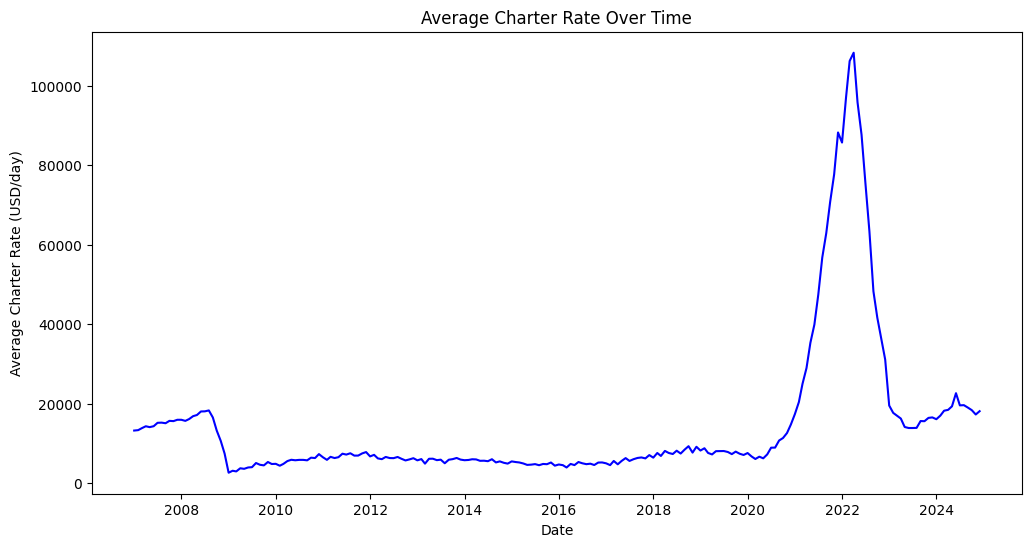

In [195]:
plt.figure(figsize=(12, 6))
plt.plot(df_combined.index, df_combined["avg_charter_rate"], label="Average Charter Rate (USD/day)", color="blue")
plt.xlabel("Date")
plt.ylabel("Average Charter Rate (USD/day)")
plt.title("Average Charter Rate Over Time")


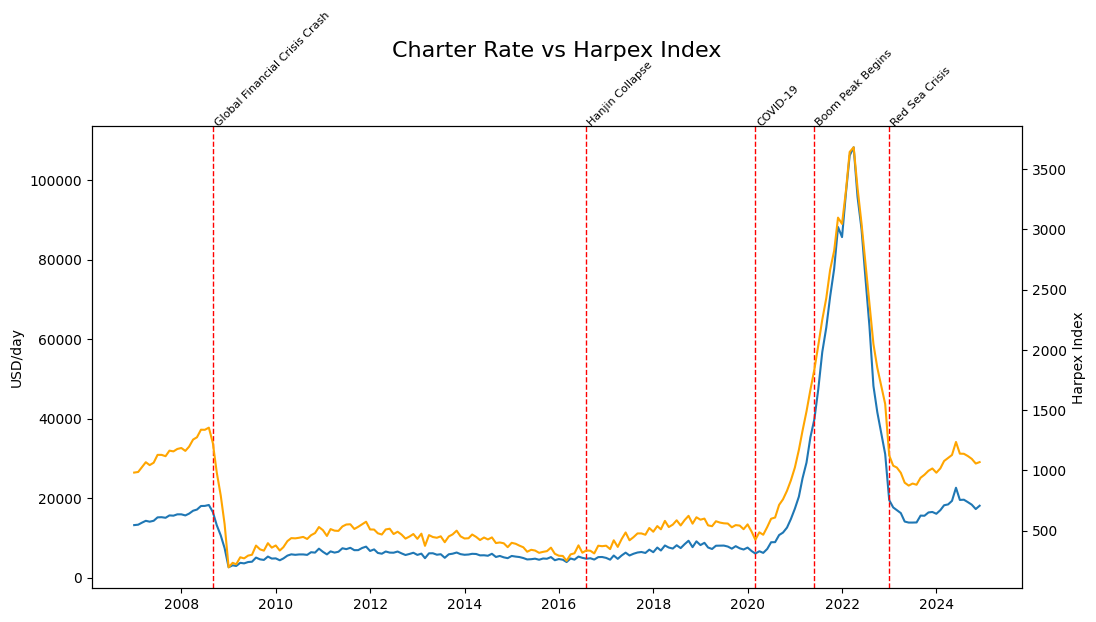

In [196]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df_combined.index, df_combined["avg_charter_rate"], label="Charter Rate")
ax1.set_ylabel("USD/day")

ax2 = ax1.twinx()
ax2.plot(df_combined.index, df_combined["harpex_index"], color="orange", label="Harpex Index")
ax2.set_ylabel("Harpex Index")

plt.title("Charter Rate vs Harpex Index", pad=50,  fontsize=16)


events= {
    "2008-9-1": "Global Financial Crisis Crash",
    "2016-08-01": "Hanjin Collapse",
    "2020-03-01": "COVID-19",
    "2021-06-01": "Boom Peak Begins",
    "2023-01-01": "Red Sea Crisis"
}

for date, event in events.items():
    ax1.axvline(pd.Timestamp(date), color="red", linestyle="--", linewidth=1)
    ax1.text(pd.Timestamp(date), ax1.get_ylim()[1], event, rotation=45, fontsize=8)
   
plt.show()

In [197]:
decomposition = seasonal_decompose(
    df_combined["avg_charter_rate"],
    model="multiplicative",
    period=12
)

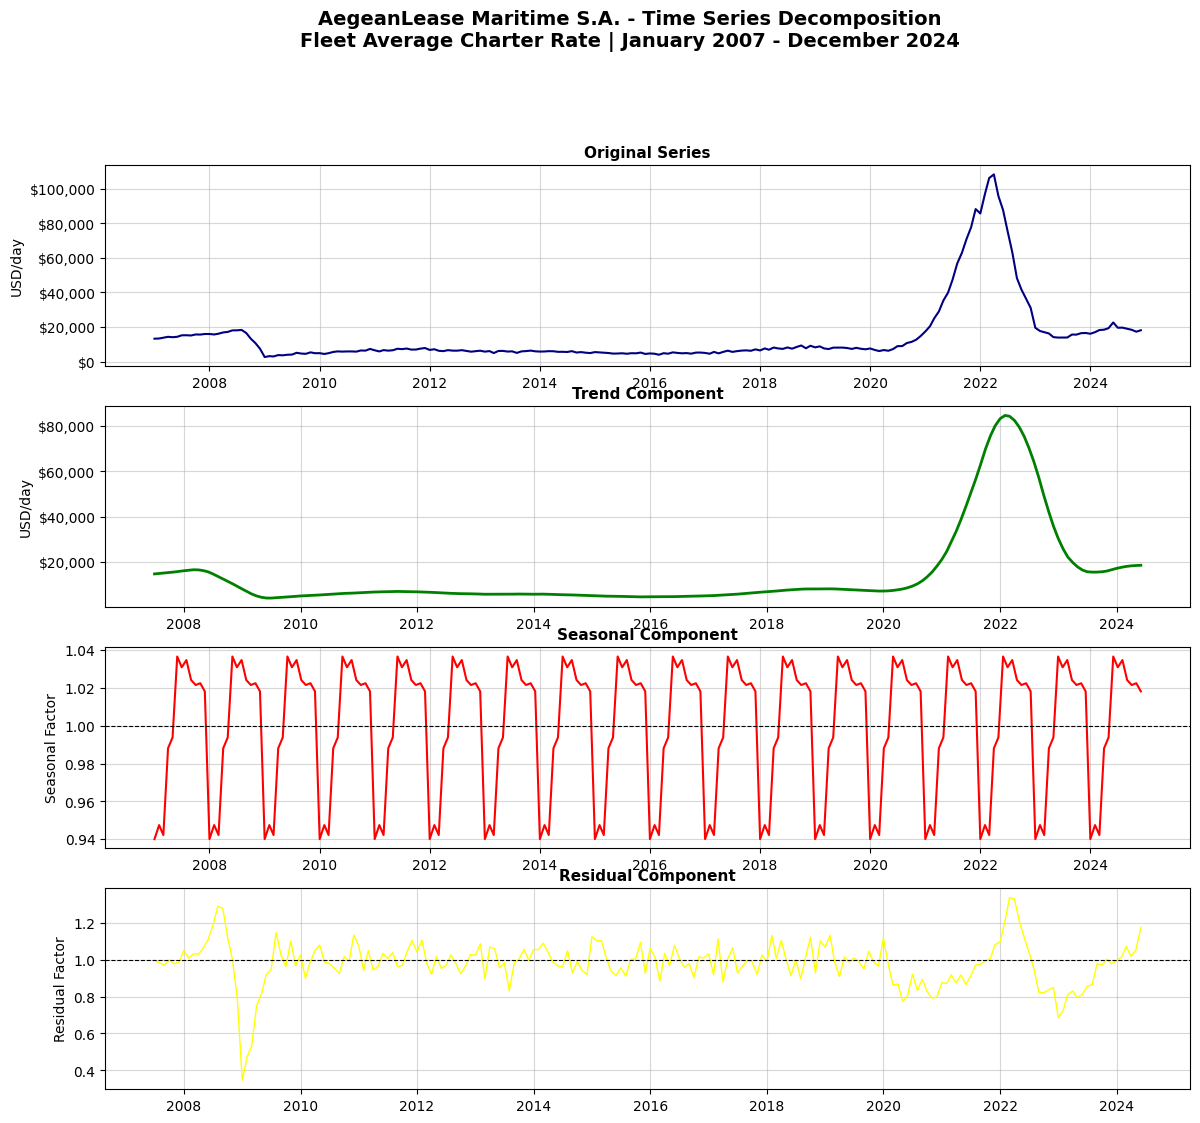

In [198]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle(
    "AegeanLease Maritime S.A. - Time Series Decomposition\n"
    "Fleet Average Charter Rate | January 2007 - December 2024",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

axes[0].plot(
    df_combined.index,
    df_combined["avg_charter_rate"],
    color="navy",
    linewidth=1.5
)
axes[0].set_ylabel("USD/day", fontsize=10)
axes[0].set_title("Original Series", fontsize=11, fontweight="bold")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x:,.0f}")
)

axes[1].plot(
    decomposition.trend.index,
    decomposition.trend,
    color="green",
    linewidth=2
)
axes[1].set_ylabel("USD/day", fontsize=10)
axes[1].set_title("Trend Component", fontsize=11, fontweight="bold")
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x:,.0f}")
)

axes[2].plot(
    decomposition.seasonal.index,
    decomposition.seasonal,
    color="red",
    linewidth=1.5
)
axes[2].set_ylabel("Seasonal Factor", fontsize=10)
axes[2].set_title("Seasonal Component", fontsize=11, fontweight="bold")
axes[2].axhline(y=1, color="black", linewidth=0.8, linestyle="--")

axes[3].plot(
    decomposition.resid.index,
    decomposition.resid,
    color="yellow",
    linewidth=1
)
axes[3].set_ylabel("Residual Factor", fontsize=10)
axes[3].set_title("Residual Component", fontsize=11, fontweight="bold")
axes[3].axhline(y=1, color="black", linewidth=0.8, linestyle="--")

for ax in axes:
    ax.grid(True, alpha=0.5)



In [199]:
adf_result = adfuller(
    df_combined["avg_charter_rate"].dropna(),
    autolag="AIC"
)

In [200]:

print("ADF TEST - RAW CHARTER RATE SERIES")

print(f"ADF Statistic:   {adf_result[0]:.4f}")
print(f"p-value:         {adf_result[1]:.4f}")
print(f"Lags Used:       {adf_result[2]}")
print(f"Observations:    {adf_result[3]}")

print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value:.4f}")

if adf_result[1] > 0.05:
    print("CONCLUSION: p > 0.05 -> FAIL TO REJECT H0")
    print("Series is NON-STATIONARY -> differencing required")
else:
    print("CONCLUSION: p < 0.05 -> REJECT H0")
    print("Series is STATIONARY -> can proceed directly")


ADF TEST - RAW CHARTER RATE SERIES
ADF Statistic:   -2.9422
p-value:         0.0407
Lags Used:       5
Observations:    210
Critical Values:
   1%: -3.4619
   5%: -2.8754
   10%: -2.5742
CONCLUSION: p < 0.05 -> REJECT H0
Series is STATIONARY -> can proceed directly


In [201]:
charter_rate_diff = df_combined["avg_charter_rate"].diff().dropna()

adf_diff = adfuller(charter_rate_diff, autolag="AIC")

print("ADF TEST - FIRST DIFFERENCED SERIES")
print(f"ADF Statistic:   {adf_diff[0]:.4f}")
print(f"p-value:         {adf_diff[1]:.4f}")
if adf_diff[1] > 0.05:
    print("CONCLUSION: p > 0.05 -> STILL NON-STATIONARY")
    print("Second differencing may be required")
else:
    print("CONCLUSION: p < 0.05 -> SERIES IS NOW STATIONARY")
    print("First differencing is sufficient -> d=1 in ARIMA")

ADF TEST - FIRST DIFFERENCED SERIES
ADF Statistic:   -5.4684
p-value:         0.0000
CONCLUSION: p < 0.05 -> SERIES IS NOW STATIONARY
First differencing is sufficient -> d=1 in ARIMA


In [202]:
charter_rate_diff = df_combined["avg_charter_rate"].diff().dropna()

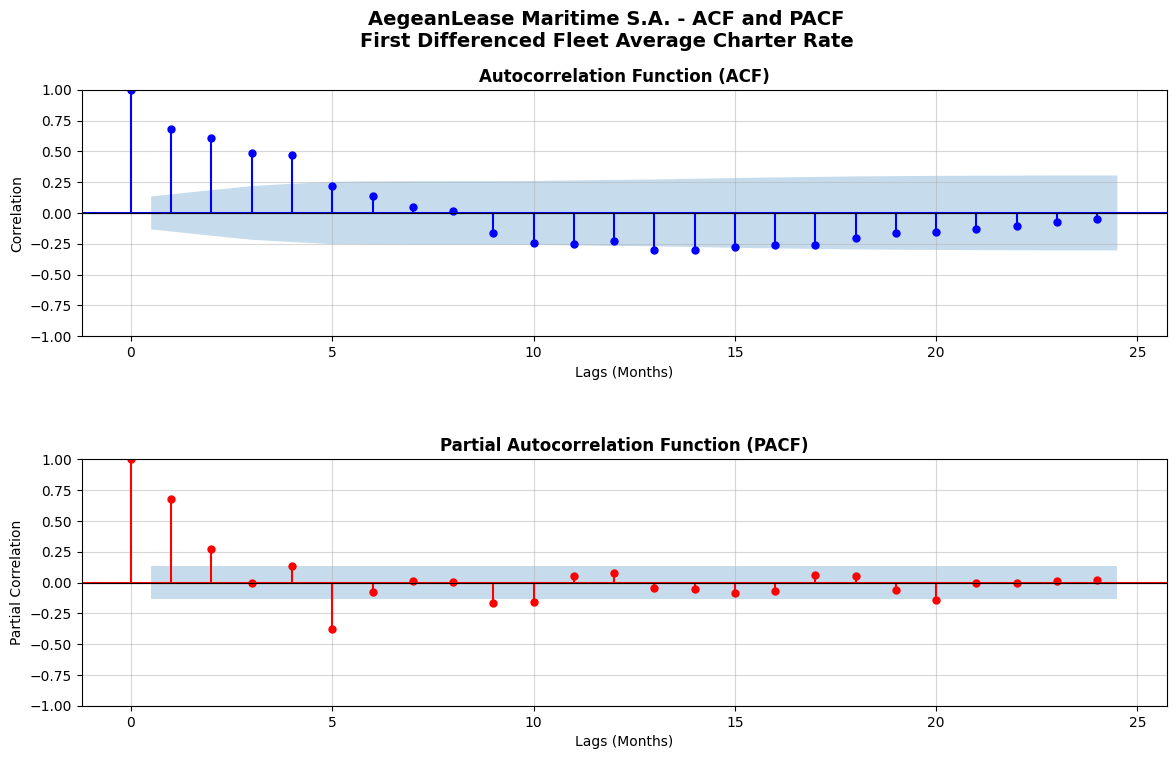

In [203]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle(
    "AegeanLease Maritime S.A. - ACF and PACF\n"
    "First Differenced Fleet Average Charter Rate",
    fontsize=14,
    fontweight="bold"
)
fig.subplots_adjust(hspace=0.5)

plot_acf(
    charter_rate_diff,
    lags=24,
    ax=axes[0],
    color="blue",
    vlines_kwargs={"colors": "blue"}
)
axes[0].set_title("Autocorrelation Function (ACF)", 
                   fontsize=12, fontweight="bold")
axes[0].set_xlabel("Lags (Months)", fontsize=10)
axes[0].set_ylabel("Correlation", fontsize=10)
axes[0].axhline(y=0, color="black", linewidth=0.8)
axes[0].grid(True, alpha=0.5)

plot_pacf(
    charter_rate_diff,
    lags=24,
    ax=axes[1],
    color="red",
    vlines_kwargs={"colors": "red"},
    method="ywm"
)
axes[1].set_title("Partial Autocorrelation Function (PACF)", 
                   fontsize=12, fontweight="bold")
axes[1].set_xlabel("Lags (Months)", fontsize=10)
axes[1].set_ylabel("Partial Correlation", fontsize=10)
axes[1].axhline(y=0, color="black", linewidth=0.8)
axes[1].grid(True, alpha=0.5)

In [204]:
series = df_combined["avg_charter_rate"].dropna()

In [205]:
train = series[series.index < "2023-01-01"]
test  = series[series.index >= "2023-01-01"]

In [206]:
candidate_models = {
    "ARIMA(2,1,2)": (2,1,2),
    "ARIMA(2,1,4)": (2,1,4),
    "ARIMA(5,1,2)": (5,1,2),
}

results_summary = {}

print("MODEL COMPARISON — AIC SCORES")

for name, order in candidate_models.items():
    model  = ARIMA(train, order=order)
    fitted = model.fit()
    results_summary[name] = {
        "order":  order,
        "aic":    fitted.aic,
        "fitted": fitted
    }
    print(f"{name}: AIC = {fitted.aic:.2f}")

MODEL COMPARISON — AIC SCORES


c:\Users\ΚΩΝΣΤΑΝΤΙΝΟΣ\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\ΚΩΝΣΤΑΝΤΙΝΟΣ\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(2,1,2): AIC = 3471.40
ARIMA(2,1,4): AIC = 3459.59


c:\Users\ΚΩΝΣΤΑΝΤΙΝΟΣ\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\ΚΩΝΣΤΑΝΤΙΝΟΣ\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(5,1,2): AIC = 3452.33


In [207]:
best_name = min(results_summary, 
                key=lambda x: results_summary[x]["aic"])
best_order  = results_summary[best_name]["order"]
best_fitted = results_summary[best_name]["fitted"]

print(f"BEST MODEL: {best_name} "
      f"(AIC = {results_summary[best_name]['aic']:.2f})")

BEST MODEL: ARIMA(5,1,2) (AIC = 3452.33)


In [208]:
forecast_test = best_fitted.forecast(steps=len(test))
forecast_test.index = test.index

In [209]:
mae  = mean_absolute_error(test, forecast_test)
rmse = np.sqrt(mean_squared_error(test, forecast_test))
mape = np.mean(np.abs((test - forecast_test) / test)) * 100
print('MODEL ACCURACY - ARIMA(5,1,2)')
print('MAE =', f'{mae:.2f} $')
print('RMSE =', f'{rmse:.2f} $')
print('MAPE =', f'{mape:.2f} %')

MODEL ACCURACY - ARIMA(5,1,2)
MAE = 14348.58 $
RMSE = 14586.80 $
MAPE = 85.61 %


In [210]:
final_model  = ARIMA(series, order=best_order)
final_fitted = final_model.fit()

In [211]:
forecast_2025 = final_fitted.get_forecast(steps=12)
forecast_mean = forecast_2025.predicted_mean
forecast_ci = forecast_2025.conf_int(alpha=0.05)

In [212]:
forecast_index = pd.date_range(
    start="2025-01-01", periods=12, freq="MS"
)
forecast_mean.index = forecast_index
forecast_ci.index = forecast_index

In [213]:
forecast_ci.iloc[:,0] = forecast_ci.iloc[:,0].clip(lower=0)

print("\n2025 CHARTER RATE FORECAST:")
for date, rate, lower, upper in zip(
    forecast_index,
    forecast_mean,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1]
):
    print(f"{date.strftime('%b %Y')}: "
          f"{rate:,.0f} $/day "
          f"(95% CI: ${lower:,.0f} – ${upper:,.0f})")


2025 CHARTER RATE FORECAST:
Jan 2025: 18,899 $/day (95% CI: $15,086 – $22,712)
Feb 2025: 19,458 $/day (95% CI: $12,715 – $26,201)
Mar 2025: 19,519 $/day (95% CI: $9,425 – $29,612)
Apr 2025: 20,216 $/day (95% CI: $6,748 – $33,684)
May 2025: 20,754 $/day (95% CI: $3,337 – $38,171)
Jun 2025: 20,881 $/day (95% CI: $0 – $41,910)
Jul 2025: 20,792 $/day (95% CI: $0 – $45,071)
Aug 2025: 21,055 $/day (95% CI: $0 – $48,350)
Sep 2025: 21,248 $/day (95% CI: $0 – $51,524)
Oct 2025: 21,158 $/day (95% CI: $0 – $54,135)
Nov 2025: 21,028 $/day (95% CI: $0 – $56,421)
Dec 2025: 21,139 $/day (95% CI: $0 – $58,798)


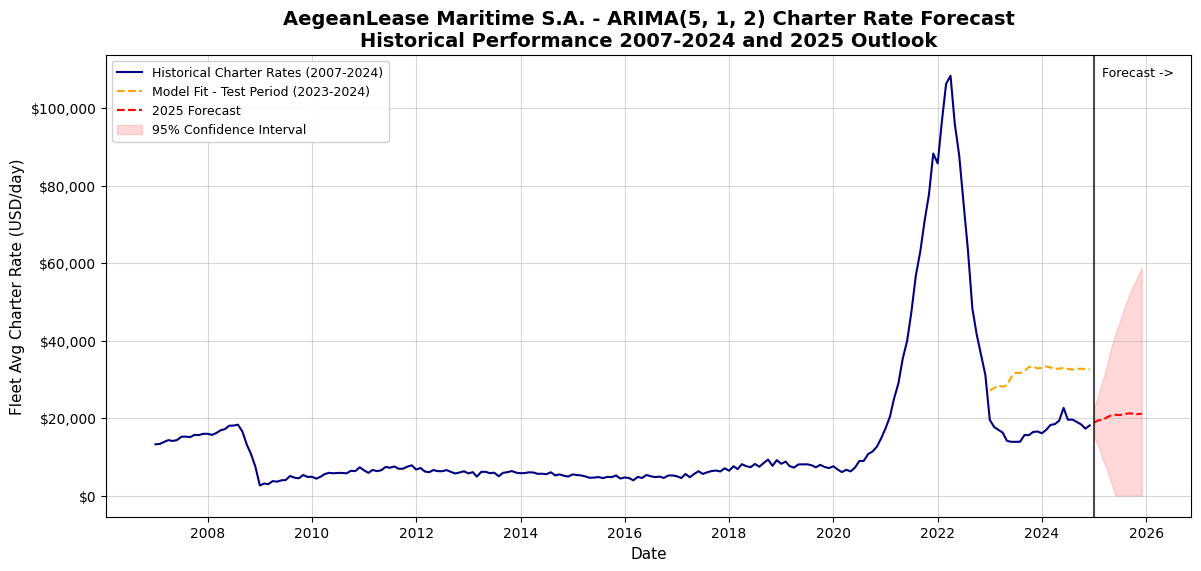

In [214]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(
    series.index,
    series,
    color="navy",
    label="Historical Charter Rates (2007-2024)"
)

ax.plot(
    test.index,
    forecast_test,
    color="orange",
    linestyle="--",
    label="Model Fit - Test Period (2023-2024)"
)

ax.plot(
    forecast_mean.index,
    forecast_mean,
    color="red",
    linestyle="--",
    label="2025 Forecast"
)

ax.fill_between(
    forecast_mean.index,
    forecast_ci.iloc[:,0],
    forecast_ci.iloc[:,1],
    color="red",
    alpha=0.15,
    label="95% Confidence Interval"
)

ax.axvline(
    pd.Timestamp("2025-01-01"),
    color="black",
    alpha=0.7
)

ax.text(
    pd.Timestamp("2025-01-01"),
    ax.get_ylim()[1] * 0.95,
    "  Forecast ->",
    fontsize=9,
    color="black"
)

ax.set_title(
    f"AegeanLease Maritime S.A. - ARIMA{best_order} Charter Rate Forecast\n"
    "Historical Performance 2007-2024 and 2025 Outlook",
    fontsize=14,
    fontweight="bold"
)
ax.set_ylabel("Fleet Avg Charter Rate (USD/day)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x:,.0f}")
)
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.5)

In [215]:
exog_cols = [
    "harpex_index",
    "bunker_price_usd_ton",
    "global_trade_volume_index"
]

In [216]:
df_model = df_combined[
    ["avg_charter_rate"] + exog_cols
].dropna()

In [217]:
df_model.head()

,avg_charter_rate,harpex_index,bunker_price_usd_ton,global_trade_volume_index
date,,,,
2007-01-01,13259.5,982.0,274.4,99.72
2007-02-01,13364.5,987.0,288.4,100.84
2007-03-01,13854.0,1026.0,290.7,102.22
2007-04-01,14341.0,1068.0,305.2,101.35
2007-05-01,14119.5,1044.0,344.7,99.68


In [218]:
train_y = df_model["avg_charter_rate"][
    df_model.index < "2023-01-01"
]
test_y = df_model["avg_charter_rate"][
    df_model.index >= "2023-01-01"
]
train_exog = df_model[exog_cols][
    df_model.index < "2023-01-01"
]
test_exog = df_model[exog_cols][
    df_model.index >= "2023-01-01"
]


In [219]:
armax_model = SARIMAX(
    train_y,
    exog=train_exog,
    order=(5, 1, 2),
    enforce_stationarity=False,
    enforce_invertibility=False
)
armax_fitted = armax_model.fit(disp=False, maxiter=500)


In [220]:
print("ARMAX(5,1,2) MODEL SUMMARY")

print(f"AIC:  {armax_fitted.aic}")
print(f"BIC:  {armax_fitted.bic}")
print("\nExogenous Variable Coefficients:")
for col in exog_cols:
    coef = armax_fitted.params[col]
    pval = armax_fitted.pvalues[col]
    sig  = "Significant" if pval < 0.05 else "Not significant"
    print(f"  {col:35s}: {coef:>10.4f}  (p={pval:.4f})  {sig}")

ARMAX(5,1,2) MODEL SUMMARY
AIC:  3052.812369925171
BIC:  3088.295583336016

Exogenous Variable Coefficients:
  harpex_index                       :    21.8723  (p=0.0000)  Significant
  bunker_price_usd_ton               :     0.6067  (p=0.7422)  Not significant
  global_trade_volume_index          :   -36.8658  (p=0.0418)  Significant


In [221]:
armax_test_forecast = armax_fitted.forecast(
    steps=len(test_y),
    exog=test_exog
)
armax_test_forecast.index = test_y.index


In [222]:
armax_mae  = mean_absolute_error(test_y, armax_test_forecast)
armax_rmse = np.sqrt(mean_squared_error(
    test_y, armax_test_forecast
))
armax_mape = np.mean(
    np.abs((test_y - armax_test_forecast) / test_y)
) * 100

In [223]:
print("ARMAX(5,1,2) ACCURACY METRICS")

print(f"MAE:  ${armax_mae:,.0f}/day")
print(f"RMSE: ${armax_rmse:,.0f}/day")
print(f"MAPE: {armax_mape:.2f}%")

print("MODEL COMPARISON: ARIMA vs ARMAX")

print(f"{'Metric':<10} {'ARIMA(5,1,2)':>15} {'ARMAX(5,1,2)':>15} {'Winner':>10}")

print(f"{'MAE':<10} {mae:>13,.0f} $ {armax_mae:>12,.0f} $ "
      f"{'ARMAX' if armax_mae < mae else 'ARIMA':>10}")
print(f"{'RMSE':<10} {rmse:>13,.0f} ${armax_rmse:>13,.0f} $ "
      f"{'ARMAX' if armax_rmse < rmse else 'ARIMA':>10}")
print(f"{'MAPE':<10} {mape:>12.2f}  % {armax_mape:>12.2f} % "
      f"{'ARMAX' if armax_mape < mape else 'ARIMA':>10}")

ARMAX(5,1,2) ACCURACY METRICS
MAE:  $8,709/day
RMSE: $9,092/day
MAPE: 51.87%
MODEL COMPARISON: ARIMA vs ARMAX
Metric        ARIMA(5,1,2)    ARMAX(5,1,2)     Winner
MAE               14,349 $        8,709 $      ARMAX
RMSE              14,587 $        9,092 $      ARMAX
MAPE              85.61  %        51.87 %      ARMAX


In [224]:
full_y = df_model["avg_charter_rate"]
full_exog = df_model[exog_cols]

armax_final = SARIMAX(
    full_y,
    exog=full_exog,
    order=(5, 1, 2),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False, maxiter=500)

In [225]:
last_year_exog = df_model[exog_cols][
    df_model.index >= "2024-01-01"
].mean()

exog_2025 = pd.DataFrame(
    [last_year_exog.values] * 12,
    columns=exog_cols,
    index=pd.date_range(
        "2025-01-01", periods=12, freq="MS"
    )
)

print("2025 Exogenous Variable Assumptions:")

for col in exog_cols:
    print(f"  {col}: {last_year_exog[col]:.2f} "
          f"(2024 average)")

2025 Exogenous Variable Assumptions:
  harpex_index: 1096.75 (2024 average)
  bunker_price_usd_ton: 595.44 (2024 average)
  global_trade_volume_index: 141.32 (2024 average)


In [226]:
armax_forecast_2025 = armax_final.get_forecast(
    steps=12,
    exog=exog_2025
)
armax_mean = armax_forecast_2025.predicted_mean
armax_ci = armax_forecast_2025.conf_int(alpha=0.05)
armax_mean.index = exog_2025.index
armax_ci.index = exog_2025.index


In [227]:
armax_ci.iloc[:,0] = armax_ci.iloc[:,0].clip(lower=0)

print("2025 ARMAX CHARTER RATE FORECAST:")

for date, rate, lower, upper in zip(
    exog_2025.index,
    armax_mean,
    armax_ci.iloc[:,0],
    armax_ci.iloc[:,1]
):
    print(f"{date.strftime('%b %Y')}: "
          f"{rate:,.0f} $/day "
          f"(95% CI: ${lower:,.0f} - ${upper:,.0f})")


2025 ARMAX CHARTER RATE FORECAST:
Jan 2025: 19,150 $/day (95% CI: $17,533 - $20,766)
Feb 2025: 19,562 $/day (95% CI: $16,931 - $22,192)
Mar 2025: 19,901 $/day (95% CI: $15,984 - $23,819)
Apr 2025: 20,356 $/day (95% CI: $15,048 - $25,663)
May 2025: 20,528 $/day (95% CI: $13,535 - $27,522)
Jun 2025: 20,662 $/day (95% CI: $12,240 - $29,084)
Jul 2025: 20,725 $/day (95% CI: $10,985 - $30,465)
Aug 2025: 20,782 $/day (95% CI: $9,839 - $31,724)
Sep 2025: 20,693 $/day (95% CI: $8,627 - $32,759)
Oct 2025: 20,612 $/day (95% CI: $7,629 - $33,596)
Nov 2025: 20,534 $/day (95% CI: $6,751 - $34,317)
Dec 2025: 20,471 $/day (95% CI: $5,976 - $34,965)


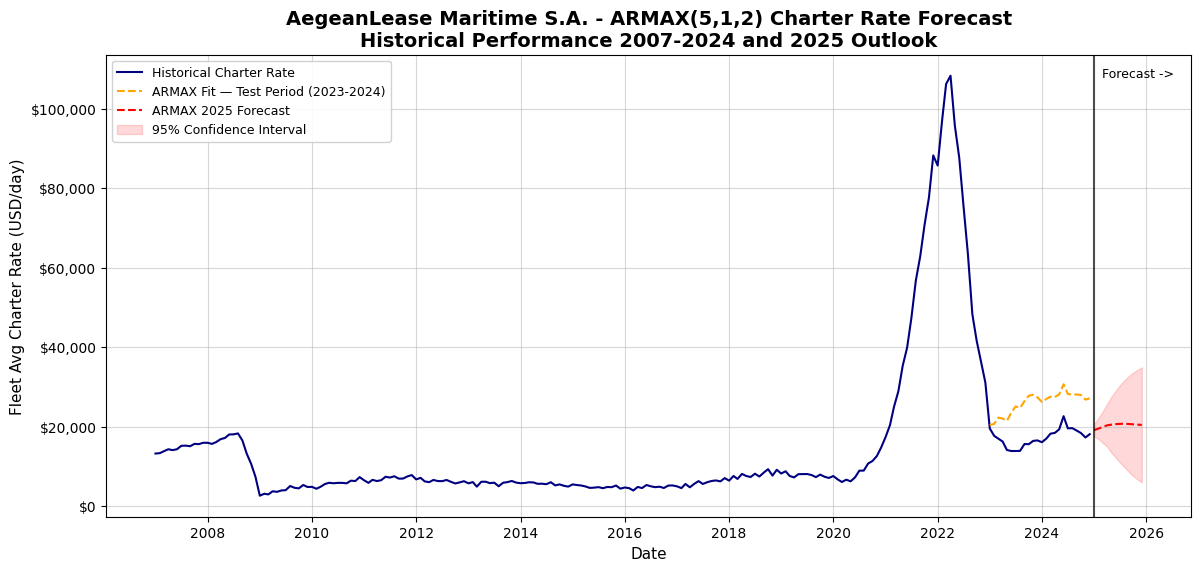

In [228]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    full_y.index, full_y,
    color="navy",
    label="Historical Charter Rate"
)

# ARMAX test period fit
ax.plot(
    armax_test_forecast.index,
    armax_test_forecast,
    color="orange",
    linestyle="--",
    label="ARMAX Fit — Test Period (2023-2024)"
)

# ARMAX 2025 forecast
ax.plot(
    armax_mean.index,
    armax_mean,
    color="red",
    linestyle="--",
    label="ARMAX 2025 Forecast"
)

# Confidence interval
ax.fill_between(
    armax_mean.index,
    armax_ci.iloc[:,0],
    armax_ci.iloc[:,1],
    color="red",
    alpha=0.15,
    label="95% Confidence Interval"
)

# Vertical separator
ax.axvline(
    pd.Timestamp("2025-01-01"),
    color="black",
    alpha=0.7
)
ax.text(
    pd.Timestamp("2025-01-01"),
    ax.get_ylim()[1] * 0.95,
    "  Forecast ->",
    fontsize=9,
    color="black"
)

# Formatting
ax.set_title(
    "AegeanLease Maritime S.A. - ARMAX(5,1,2) Charter Rate Forecast\n"
    "Historical Performance 2007-2024 and 2025 Outlook",
    fontsize=14,
    fontweight="bold"
)
ax.set_ylabel("Fleet Avg Charter Rate (USD/day)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"${x:,.0f}")
)
ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.5)